In [1]:
import os 
import sys

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)

In [2]:

import re

import math
import io
import torch
from torchvision import transforms
import numpy as np
import torch.nn as nn

from glob import glob

import FASCINATION.src.utils as utils 

from pathlib import Path

import hydra
from omegaconf import OmegaConf

from tqdm import tqdm

from PIL import Image

from scipy.ndimage import convolve


import matplotlib.pyplot as plt

from pytorch_msssim import ms_ssim

from FASCINATION.src.utils import loading_datamodule, unorm_ssp_arr_3D

from scipy.interpolate import interp1d

from scipy.signal import butter, filtfilt

import pickle 


In [3]:
from compressai.zoo import (bmshj2018_factorized, bmshj2018_hyperprior, mbt2018_mean, mbt2018, cheng2020_anchor)

In [4]:
from MLIC.models import MLICPlusPlus #MLIC piped and added to external path
from MLIC_copy.MLIC.models import MLICPlusPlus as RGB_MLICPlusPlus

In [5]:
from MLIC.utils.utils import Config
#from MLIC.config.args import test_options

In [6]:
import scienceplots
plt.style.use('science')
#plt.style.use(['science','ieee'])
plt.rcParams.update({'figure.dpi': '100'}) #if IEEE and plt.show is used

# Functions

In [7]:
def float_to_rgb_image(arr):
    """
    Encode a 2D float32 array (in [0, 1]) into a 3-channel RGB uint8 image.
    """
    assert arr.ndim == 2, "Input must be 2D (H, W)"
    arr = np.clip(arr, 0, 1)
    val = (arr * (256**3 - 1)).astype(np.uint32)  # scale to [0, 16777215]

    r = (val >> 16) & 0xFF
    g = (val >> 8) & 0xFF
    b = val & 0xFF

    rgb = np.stack([r, g, b], axis=-1).astype(np.uint8)  # shape: (H, W, 3)
    return rgb

def save_float_array_as_png(arr, path):
    rgb_img = float_to_rgb_image(arr)
    img = Image.fromarray(rgb_img, mode="RGB")
    img.save(path)

In [8]:
def rgb_image_to_float(arr):
    """
    Decode a 3-channel RGB uint8 image (H, W, 3) back to float32 array in [0, 1].
    """
    r = arr[..., 0].astype(np.uint32)
    g = arr[..., 1].astype(np.uint32)
    b = arr[..., 2].astype(np.uint32)

    val = (r << 16) | (g << 8) | b
    return val.astype(np.float32) / (256**3 - 1)

def load_float_array_from_png(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img)
    return rgb_image_to_float(arr)

In [9]:
def rgb_image_to_float_tensor(tensor):
    """
    Decode a 3-channel RGB float32 tensor (C, H, W) in [0, 1] back to a float32 array in [0, 1].
    """
    assert tensor.ndim == 3 and tensor.size(0) == 3, "Input must be a 3-channel tensor (C, H, W)"
    
    # Scale tensor to uint32 range
    tensor = (tensor * (256**3 - 1)).to(torch.uint32)
    
    # Extract RGB channels
    r = (tensor[0] << 16)
    g = (tensor[1] << 8)
    b = tensor[2]
    
    # Combine channels and normalize
    val = r + g + b
    return val.to(torch.float32) / (256**3 - 1)

In [10]:
def get_min_max_idx(arr,axs=1, pad=True):
    grad = np.diff(arr,axis=axs)
    grad_sign = np.sign(grad)
    min_max = np.diff(grad_sign,axis=axs) 
    min_max = np.abs(np.sign(min_max))
    if pad:
        min_max = np.pad(min_max, ((0,0),(1,1),(0,0),(0,0)), 'constant', constant_values=1)
    return min_max


In [11]:
def cubic_interpolate_along_axis(arr: np.ndarray, target_size: int, axis: int) -> np.ndarray:
    """
    Interpolates a NumPy array along a specified axis using cubic splines.

    Parameters:
        arr (np.ndarray): Input array of arbitrary shape.
        target_size (int): Desired size along the interpolation axis.
        axis (int): Axis to interpolate along.

    Returns:
        np.ndarray: Interpolated array with the same shape except along `axis`.
    """
    original_shape = arr.shape
    current_size = arr.shape[axis]

    # Generate old and new coordinate grids normalized to [0, 1]
    x_old = np.linspace(0, 1, current_size)
    x_new = np.linspace(0, 1, target_size)

    # Move the axis to interpolate to the front for easier broadcasting
    arr_swapped = np.moveaxis(arr, axis, 0)  # Shape: (current_size, ...)
    reshaped = arr_swapped.reshape(current_size, -1)  # Shape: (current_size, -1)

    # Perform interpolation
    f = interp1d(x_old, reshaped, kind='cubic', axis=0, bounds_error=False, fill_value="extrapolate")
    interpolated = f(x_new)  # Shape: (target_size, -1)

    # Reshape back and move axis to original position
    new_shape = (target_size,) + arr_swapped.shape[1:]
    interpolated = interpolated.reshape(new_shape)
    return np.moveaxis(interpolated, 0, axis)

In [12]:
def get_f1_score(min_max_idx_truth, min_max_idx_ae, axs=1, kernel_size=10):



    # Define the kernel based on the shape of the truth array
    kernel_shape = [1] * min_max_idx_truth.ndim
    kernel_shape[axs] = kernel_size  # Set the size of the kernel along the specified axis
    kernel = np.ones(kernel_shape)

    # Expand the truth array with the kernel
    truth_expanded = convolve(min_max_idx_truth, kernel, mode='constant', cval=0.0)
    ae_expanded = convolve(min_max_idx_ae, kernel, mode='constant', cval=0.0)

    # Compute the true positives
    true_positives = (truth_expanded > 0) & (min_max_idx_ae > 0)
    num_true_positives = np.sum(true_positives, axis=axs)

    # Compute the false positives
    false_positives = (truth_expanded == 0) & (min_max_idx_ae > 0)
    num_false_positives = np.sum(false_positives, axis=axs)

    # Compute the false negatives
    false_negatives = (min_max_idx_truth > 0) & (ae_expanded == 0)
    num_false_negatives = np.sum(false_negatives, axis=axs)

    # Compute precision and recall while avoiding division by zero
    precision_den = num_true_positives + num_false_positives
    recall_den = num_true_positives + num_false_negatives

    precision_score = np.where(precision_den == 0, 0, num_true_positives / precision_den)
    recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)

    # Compute f1_score and avoid division by zero when both precision and recall are 0
    sum_scores = precision_score + recall_score
    f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)

    return f1_score

In [13]:
def compute_psnr(a, b):
    mse = np.mean((a - b) ** 2)
    return -10 * np.log10(mse)

In [14]:

def compute_msssim(a, b):
    return ms_ssim(a, b, data_range=1.).item()

In [15]:

def compute_bpp(out_net):
    size = out_net['x_hat'].size()
    num_pixels = size[0] * size[2] * size[3]
    return sum(torch.log(likelihoods).sum() / (-math.log(2) * num_pixels)
              for likelihoods in out_net['likelihoods'].values()).item()

def compute_total_bits(out_net):
    return sum(torch.log(likelihoods).sum() / (-math.log(2))
              for likelihoods in out_net['likelihoods'].values()).item()

def compute_bits_per_sample(out_net):
    num_sample = out_net['x_hat'].size(0)
    return sum(torch.log(likelihoods).sum() / (-math.log(2)*num_sample)
              for likelihoods in out_net['likelihoods'].values()).item()

def compute_bits_per_elements(out_net):
    size = out_net['x_hat'].numel()
    return sum(torch.log(likelihoods).sum() / (-math.log(2) * size)
              for likelihoods in out_net['likelihoods'].values()).item()


def compute_compression_rate(out_net, bits_per_channel=8):
    original_bits = out_net['x_hat'].numel() * bits_per_channel
    compressed_bits = sum(
        -torch.log(likelihoods).sum() / math.log(2)
        for likelihoods in out_net['likelihoods'].values()
    ).item()
    return original_bits / compressed_bits

# Load data

In [16]:
pca_file = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_pca_all_components_with_pooling_upsampling_unorm_xp_autoencoder_V2_dif_pca_V2.pkl"

with open(pca_file, "rb") as file:
    pca_rmse_dict = pickle.load(file)  




In [17]:
import pandas as pd

# Load the CSV file into a DataFrame
space_depth_pca_metrics_df = pd.read_csv("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/space_depth_pca_metrics.csv")

# Display the first few rows
space_depth_pca_metrics_df.head() 

,Unnamed: 0,CR,RMSE,PSNR,MS-SSIM,ECS,MAE,mean_error_n_min_max,F1_score,R2_score
0,0.50,1.055040e+06,4.396561,-12.862261,0.642869,187.867688,2.949677,1.377386,0.372025,0.920669
1,0.80,3.768000e+05,3.416507,-10.671645,0.655022,118.514924,2.183834,1.597320,0.409203,0.952095
2,0.90,1.648500e+05,2.803282,-8.953337,0.724499,116.177054,1.854916,1.554976,0.434059,0.967749
3,0.95,9.420000e+04,2.398217,-7.597771,0.769397,113.526535,1.624954,1.522568,0.453118,0.976396
4,0.98,2.791111e+04,1.582107,-3.984718,0.848602,96.631155,1.061865,1.478810,0.527206,0.989727


In [18]:
season_csv = {"all": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_all_pca_metrics.csv",
              "summer": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_summer_pca_metrics.csv",
              "winter": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_winter_pca_metrics.csv",
              "spring": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_spring_pca_metrics.csv",
              "autumn": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_autumn_pca_metrics.csv"}  

season_dfs = {season: pd.read_csv(path) for season, path in season_csv.items()}

In [19]:
all_pca_metrics_df = pd.read_csv("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_all_pca_metrics.csv")

# Display the first few rows
all_pca_metrics_df

,Unnamed: 0,CR,RMSE,PSNR,MS-SSIM,ECS,MAE,mean_error_n_min_max,F1_score,R2_score,n_depth,m_spatial,k_time
0,0.50,2.543400e+06,5.983541,-15.539166,0.485674,199.915158,4.009138,1.208625,0.342007,0.852132,1,4,2
1,0.80,7.266857e+05,5.737482,-15.174427,0.492774,200.203480,3.852917,1.255221,0.350792,0.864043,1,13,7
2,0.90,5.652000e+05,4.995463,-13.971515,0.507419,155.189241,3.216626,1.451550,0.355821,0.896935,2,15,9
3,0.95,2.826000e+05,4.778045,-13.585005,0.520836,150.736666,3.101029,1.447956,0.368754,0.905711,2,29,18
4,0.98,1.374811e+05,4.484714,-13.034694,0.538476,131.865364,2.919984,1.436303,0.384950,0.916933,3,67,37


In [20]:
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_3_depth.pkl", "rb") as f:
    model_metrics = pickle.load(f)


# Load models

In [21]:
# data_path ={"enatl": "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc",
#             "natl": "/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_sound_speed_regrid_0_botm.nc"}

In [22]:
# try:
#     if dm_dict:
#         print("Not reloading datamodule")

# except:
    
#     dm_dict = {}
    
#     n_components = 0
#     print("Initializing datamodule")

In [23]:
# xp="autoencoder_V2"
# cfg_path = f"/Odyssey/private/o23gauvr/code/FASCINATION/config/xp/{xp}.yaml"
# cfg = OmegaConf.load(cfg_path)

In [24]:
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/natl_dm_4_157_196_256.pkl", "rb") as f_rgb:
    dm = pickle.load(f_rgb)

In [25]:
depth_array = dm.depth_array
test_ssp_arr = dm.test_da.data 

In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
metric = 'mse'  # only pre-trained model for mse are available for now
quality = 5     # lower quality -> lower bit-rate (use lower quality to clearly see visual differences in the notebook)

In [27]:
mlic_config = Config({
    "N": 192,
    "M": 320,
    "slice_num": 10,
    "context_window": 5,
    "act": nn.GELU,
})

mlic_config

{'N': 192,
 'M': 320,
 'slice_num': 10,
 'context_window': 5,
 'act': torch.nn.modules.activation.GELU}

In [28]:
# mlic_args = test_options()
# mlic_args

In [29]:
# networks = {
#     'bmshj2018-factorized': bmshj2018_factorized(quality=quality, pretrained=True).eval().to(device), #'bmshj2018-hyperprior': bmshj2018_hyperprior(quality=quality, pretrained=True).eval().to(device),
#     'mbt2018-mean': mbt2018_mean(quality=quality, pretrained=True).eval().to(device), #    'mbt2018': mbt2018(quality=quality, pretrained=True).eval().to(device),
#     'cheng2020-anchor': cheng2020_anchor(quality=quality, pretrained=True).eval().to(device),
#     'mlic++': mlic_net
# }

# reconstruct profile from png

## depth channels

In [30]:
png_path = "/Odyssey/private/o23gauvr/input/imgs/depth_channels_3/test/"


In [31]:
from glob import glob

# List all PNG files in the directory
png_files = glob(f"{png_path}/*.png")

png_files[-1]

'/Odyssey/private/o23gauvr/input/imgs/depth_channels_3/test/natl_033_group_49.png'

In [32]:
img = Image.oimg = Image.open('/Odyssey/private/o23gauvr/input/imgs/depth_channels_3/test/natl_033_group_51.png').convert('RGB')
x = transforms.ToTensor()(img).unsqueeze(0).to(device)

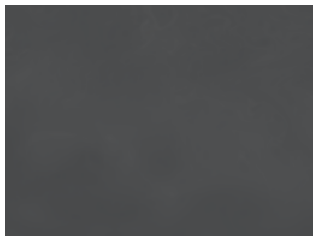

In [33]:
%matplotlib inline
plt.figure(figsize=(6, 3))
plt.axis('off')
plt.imshow(img)
plt.show()

### run models

In [34]:
outputs = {}
with torch.no_grad():
    for name, net in networks.items():
        rv = net(x)
        rv['x_hat'].clamp_(0, 1)
        outputs[name] = rv

NameError: name 'networks' is not defined

### Plot output

In [ ]:
reconstructions = {name: transforms.ToPILImage()(out['x_hat'].squeeze())
                  for name, out in outputs.items()}

In [ ]:
diffs = [torch.mean((out['x_hat'] - x).abs(), axis=1).squeeze()
        for out in outputs.values()]

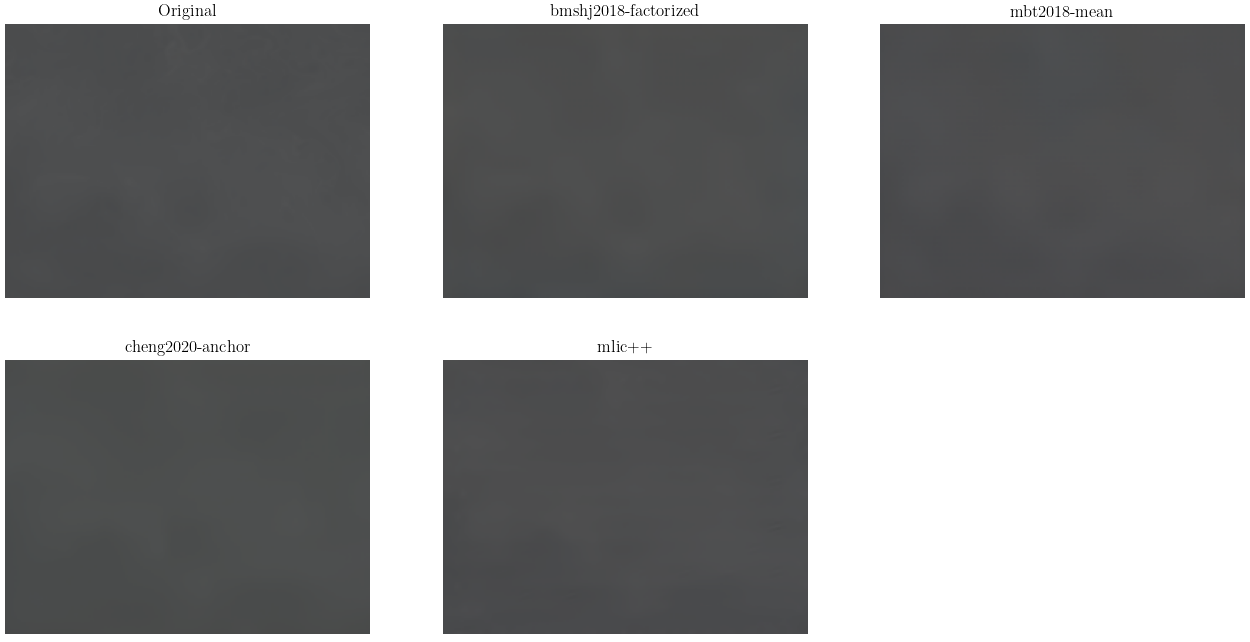

In [ ]:
%matplotlib inline
fix, axes = plt.subplots((len(reconstructions) + 2)// 3, 3, figsize=(16, 8))
for ax in axes.ravel():
    ax.axis('off')
   
axes.ravel()[0].imshow(img) #.crop((468, 212, 768, 512))
axes.ravel()[0].title.set_text('Original')
    
for i, (name, rec) in enumerate(reconstructions.items()):
    axes.ravel()[i + 1].imshow(rec) #.crop((468, 212, 768, 512)) # cropped for easy comparison
    axes.ravel()[i + 1].title.set_text(name)

plt.show()

# Reconstruct from dm

In [29]:
# level = 3
# file_name = {1:"depth",3:"group"}


# png_path = Path(f"/Odyssey/private/o23gauvr/input/imgs/depth_channels_{level}/test/")
# last_file = sorted(glob(f"{png_path}/{data}*.png"), key=lambda x: [int(n) for n in re.findall(r'\d+', x)])[-1]
# max_imgs, _, max_group = last_file.split("_")[-3:]
# max_group = int(max_group.split('.')[0])
# max_imgs = int(max_imgs)

#x_min, x_max = dm.norm_stats.params.values()

selected_models = ['mlic++'] #'mbt2018-mean'  #'cheng2020-anchor','bmshj2018-factorized','mlic++'  # Add others like 'bmshj2018-factorized', etc.

if 'mlic++' in selected_models:
    rgb_mlic_net = RGB_MLICPlusPlus(config=mlic_config).eval().to(device)
    rgb_mlic_checkpoint = torch.load("/Odyssey/private/o23gauvr/code/MLIC/checkpoints/mlicpp_mse_q5_2960000.pth.tar")
    rgb_mlic_net.load_state_dict(rgb_mlic_checkpoint['state_dict'])
    
    mlic_net = MLICPlusPlus(config=mlic_config).eval().to(device)
    mlic_checkpoint = torch.load("/Odyssey/private/o23gauvr/code/MLIC/experiments/mlicpp_on_ssp/checkpoints/checkpoint_best_loss.pth.tar")
    mlic_net.load_state_dict(mlic_checkpoint['state_dict'])
    
# Initialize containers
bit_rates = {}
outputs = {}

# Loop over quality levels
for i,quality in enumerate(range(1, 6)):
    print(f"\n===== Processing quality {quality} =====\n")
    #unrgb_truth_arr = np.zeros(test_ssp_arr.shape)

    # Instantiate models for this quality
    networks = {}
    for name in selected_models:
        if name == 'mbt2018-mean':
            networks[name] = mbt2018_mean(quality=quality, pretrained=True).eval().to(device)
        elif name == 'bmshj2018-factorized':
            networks[name] = bmshj2018_factorized(quality=quality, pretrained=True).eval().to(device)
        elif name == 'cheng2020-anchor':
            networks[name] = cheng2020_anchor(quality=quality, pretrained=True).eval().to(device)
        elif name == 'mlic++' and i==0:
            networks['rgb mlic++'] = rgb_mlic_net.to(device)
            networks['ssp mlic++'] = mlic_net.to(device)


    for name, net in tqdm(networks.items(), desc=f"Networks @ quality {quality}"):

        if name not in bit_rates:
            bit_rates[name] = {}
            outputs[name] = {}

        reconstructed_arr = np.zeros(test_ssp_arr.shape)

        total_bits = 0
        total_elements = 0
        total_original_bits = 0

        if name == 'ssp mlic++':

            x = torch.tensor(test_ssp_arr.copy()).to(device)

            with torch.no_grad():
                rv = net(x)

            bits = compute_total_bits(rv)
            numel = rv['x_hat'].numel()
            original_bits = numel * 8

            total_bits += bits
            total_elements += numel
            total_original_bits += original_bits

            reconstructed_arr = rv['x_hat'].detach().cpu().numpy() #.transpose(0, 2, 3, 1)

        else:

            n_imgs = len(depth_array)//3

            for j in range(n_imgs):

                start_idx = j * 3   
                end_idx = start_idx + 3

                x = torch.tensor(test_ssp_arr[:,start_idx:end_idx,:,:].copy()).to(device)

                with torch.no_grad():
                    rv = net(x)

                bits = compute_total_bits(rv)
                numel = rv['x_hat'].numel()
                original_bits = numel * 8

                total_bits += bits
                total_elements += numel
                total_original_bits += original_bits

                # arr = np.array(transforms.ToPILImage(mode="RGB")(rv['x_hat'].squeeze()))

                # arr = arr.astype(np.float32).transpose(2,0,1) / 255.0
                #unrgb_truth_arr[i, i:i+3] = np.array(img).astype(np.float32).transpose(2,0,1) / 255.0


                reconstructed_arr[:, start_idx:end_idx] = rv['x_hat'].detach().cpu().numpy() #.transpose(0, 2, 3, 1)


        bpe = total_bits / total_elements
        cr = total_original_bits / total_bits

        bit_rates[name][cr] = {
            "bits_per_element": bpe,
            "compression_rate": cr,
            "total_compressed_bits": total_bits,
            "total_original_bits": total_original_bits
        }

        unorm_reconstructed_arr = unorm_ssp_arr_3D(reconstructed_arr, dm)
        unorm_truth_arr = unorm_ssp_arr_3D(test_ssp_arr, dm)
        outputs[name][cr] = reconstructed_arr

    rmse = np.sqrt(np.mean((unorm_reconstructed_arr - unorm_reconstructed_arr) ** 2))
    print(f"RMSE: {rmse:.4f}")


for name, stats_dict in bit_rates.items():
    print(f"\n===== {name} =====\n")
    for cr, stats in stats_dict.items():
        print(f"Compression rate: {cr:.2f}x, "
              f"Bits per element: {stats['bits_per_element']:.4f}, "
              f"Total compressed bits: {stats['total_compressed_bits']:.2f}, "
              f"Total original bits: {stats['total_original_bits']:.2f}")

/Odyssey/private/o23gauvr/miniforge3/envs/fsc_env/lib/python3.8/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]



===== Processing quality 1 =====



Networks @ quality 1: 100%|██████████| 2/2 [00:07<00:00,  3.83s/it]


RMSE: 0.0000

===== Processing quality 2 =====



Networks @ quality 2: 0it [00:00, ?it/s]


...

RMSE: 0.0000

===== Processing quality 4 =====



Networks @ quality 4: 0it [00:00, ?it/s]


RMSE: 0.0000

===== Processing quality 5 =====



Networks @ quality 5: 0it [00:00, ?it/s]


RMSE: 0.0000

===== rgb mlic++ =====

Compression rate: 368.44x, Bits per element: 0.0217, Total compressed bits: 5660632.15, Total original bits: 2085617664.00

===== ssp mlic++ =====

Compression rate: 4814.37x, Bits per element: 0.0017, Total compressed bits: 435983.88, Total original bits: 2098987008.00


In [45]:
# y_zero_count = torch.sum(rv["likelihoods"]["y_likelihoods"] == 0).item()
# z_zero_count = torch.sum(rv["likelihoods"]["z_likelihoods"] == 0).item()

# print(f"Number of zeros in y_likelihoods: {y_zero_count}")
# print(f"Number of zeros in z_likelihoods: {z_zero_count}")

In [47]:
# best_rmse = float('inf')
# best_Wn = None

# # Define a range of Wn values to test
# Wn_values = np.linspace(0.1, 1, 10)

# for Wn in Wn_values:
#     b, a = butter(N=2, Wn=Wn, btype='low', analog=False)
#     filtered_ae_test_arr = filtfilt(b, a, reconstructed_arr[:, :-1, :, :], axis=1)
#     rmse = np.sqrt(np.mean((filtered_ae_test_arr - test_ssp_arr[:, :-1, :, :]) ** 2))
    
#     if rmse < best_rmse:
#         best_rmse = rmse
#         best_Wn = Wn

#     print(f"Wn: {Wn:.3f}, RMSE: {rmse:.4f}")

# print(f"\nBest Wn: {best_Wn:.3f} with RMSE: {best_rmse:.4f}")

In [48]:
# best_f1_score = -float('inf')
# best_Wn = None

# # Define a range of Wn values to test
# Wn_values = np.linspace(0.1, 0.13, 10)

# for Wn in Wn_values:
#     b, a = butter(N=2, Wn=Wn, btype='low', analog=False)
#     filtered_ae_test_arr = filtfilt(b, a, reconstructed_arr[:, :-1, :, :], axis=1)
    
#     # Compute min-max indices
#     min_max_idx_truth = get_min_max_idx(test_ssp_arr[:, :-1, :, :], pad=False)
#     min_max_idx_ae = get_min_max_idx(filtered_ae_test_arr, pad=False)
    
#     # Compute F1 score
#     F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae)
#     f1_score = np.mean(F1_score)
    
#     if f1_score > best_f1_score:
#         best_f1_score = f1_score
#         best_Wn = Wn

#     print(f"Wn: {Wn:.3f}, F1 Score: {f1_score:.4f}")

# print(f"\nBest Wn: {best_Wn:.3f} with F1 Score: {best_f1_score:.4f}")

Wn: 0.100, F1 Score: 0.7576
Wn: 0.103, F1 Score: 0.7587
Wn: 0.107, F1 Score: 0.7592
Wn: 0.110, F1 Score: 0.7589
Wn: 0.113, F1 Score: 0.7579
Wn: 0.117, F1 Score: 0.7565
Wn: 0.120, F1 Score: 0.7543
Wn: 0.123, F1 Score: 0.7517
Wn: 0.127, F1 Score: 0.7487
Wn: 0.130, F1 Score: 0.7455

Best Wn: 0.107 with F1 Score: 0.7592

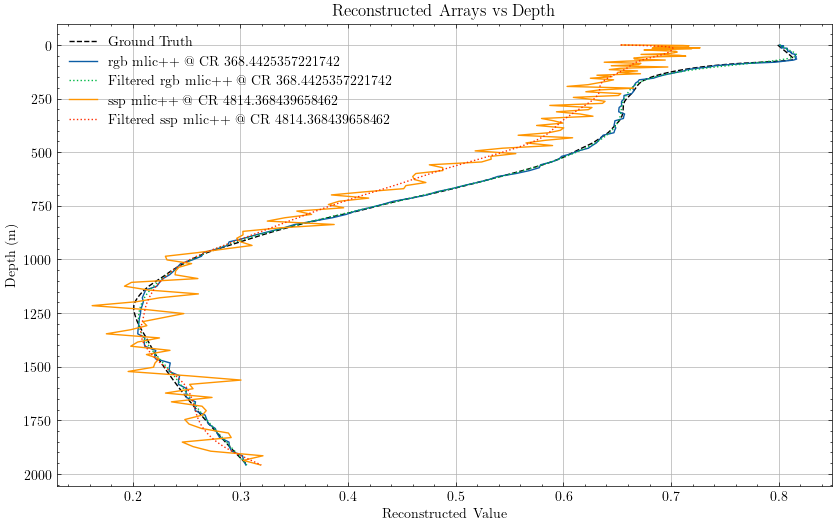

In [ ]:
# Plot Reconstructed Arrays
plt.figure(figsize=(10, 6))

# Plot ground truth
plt.plot(test_ssp_arr[10, :-1, 10, 10], depth_array[:-1], label="Ground Truth", linestyle="--", color="black")

# Plot reconstructed arrays
for model_name, cr_dict in outputs.items():
    for cr, reconstructed_arr in cr_dict.items():
        # Plot original reconstructed array
        plt.plot(reconstructed_arr[10, :-1, 10, 10], depth_array[:-1], label=f"{model_name} @ CR {cr}")

        # # Apply filtering
        # b, a = butter(N=2, Wn=0.107, btype='low', analog=False)
        # filtered_profile = filtfilt(b, a, reconstructed_arr[10, :-1, 10, 10])

        # # Plot filtered reconstructed array
        # plt.plot(filtered_profile, depth_array[:-1], label=f"Filtered {model_name} @ CR {cr}", linestyle=":")

plt.gca().invert_yaxis()  # Invert y-axis to show depth increasing downward
plt.xlabel("Reconstructed Value")
plt.ylabel("Depth (m)")
plt.title("Reconstructed Arrays vs Depth")
plt.legend()
plt.grid()
plt.show()

In [50]:
ckpt_dict = {}

base_dir = "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics"


# List the first-level directories in the base directory
first_level_dirs = next(os.walk(base_dir))[1]

# Iterate through the first-level directories
for dir_name in first_level_dirs:
    if dir_name == "mute":
        continue
    # Create the relative path
    relative_path = os.path.join(base_dir, dir_name)
    # Add to the dictionary
    ckpt_dict[dir_name] = relative_path

# Print the dictionary
print(ckpt_dict)


{'CAE': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics/CAE', 'CAE pooled by factor 4x4': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics/CAE pooled by factor 4x4', 'CAE pooled by factor 8x8': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics/CAE pooled by factor 8x8'}


In [51]:
for model_carac in ckpt_dict.keys():

    ckpt_list =  list(Path(ckpt_dict[model_carac]).rglob('*.ckpt'))
    print(f"Model {model_carac} with {len(ckpt_list)} checkpoints")

Model CAE with 9 checkpoints
Model CAE pooled by factor 4x4 with 8 checkpoints
Model CAE pooled by factor 8x8 with 8 checkpoints


In [52]:
ckpt_list = list(Path(ckpt_dict[model_carac]).rglob('*.ckpt'))

for model_carac in tqdm(ckpt_dict.keys(), desc="Models"):
    ckpt_list = list(Path(ckpt_dict[model_carac]).rglob('*.ckpt'))

    outputs[model_carac] = {}
    bit_rates[model_carac] = {}
        
    for ckpt_path in ckpt_list:
        ckpt_path = str(ckpt_path)

        
        model_name = " ".join((ckpt_path.split("AE")[-1]).split("/")).replace("_", "  ")
        print(f"\n{model_name}")

        # if params["filtering"]:
        #     for sub_dic in filtered_ae_rmse_dict.values():
        #         sub_dic[model_carac] = {}
        

        try:
            cfg = utils.get_cfg_from_ckpt_path(ckpt_path, pprint=False)
        except:
            print(f"Can't load config")
            continue


        if cfg.datamodule in list(dm_dict.keys()):
            dm = dm_dict[cfg.datamodule]
            truth_ssp, _ = utils.loading_datamodule_phase(dm, phase="test")
            ae_test_ssp_tens = torch.tensor(truth_ssp, dtype=getattr(torch, cfg.dtype), device=device)
        
        else:
            dm = hydra.utils.call(cfg.datamodule)
            truth_ssp, dm = utils.loading_datamodule_phase(dm, phase="test")
            ae_test_ssp_tens = torch.tensor(truth_ssp, dtype=getattr(torch, cfg.dtype), device=device)
            dm_dict[cfg.datamodule] = dm


        try:
            lit_model = utils.load_model(ckpt_path, dm, ae_test_ssp_tens, verbose=True)
        except:
            print(f"Can't load model")
            continue

        ssp_ae_test_arr = lit_model(ae_test_ssp_tens).detach().cpu().numpy().astype(truth_ssp.dtype)

        cr = lit_model.model_AE.cr
        bpe = lit_model.model_AE.bpe
        total_bits = lit_model.model_AE.total_bits

        
        if dm.norm_stats["norm_location"] == "datamodule":
            ssp_ae_test_arr = utils.unorm_ssp_arr_3D(ssp_ae_test_arr, dm)
            
            

        outputs[model_carac][cr] = ssp_ae_test_arr

        # Store the total bit rate for the current network
        bit_rates[model_carac][cr] = {
            "bits_per_element": bpe,
            "compression_rate": cr,
            "total_compressed_bits": total_bits
        }
        

if dm.norm_stats["norm_location"] == "datamodule":
    truth_ssp = utils.unorm_ssp_arr_3D(truth_ssp, dm)

Models:   0%|          | 0/3 [00:00<?, ?it/s]


 channels  [5000, 3000, 1000, 100] upsample  mode  trilinear linear  layer  False cr  100000 1  conv  per  layer padding  cubic interp  size  5 final  upsample  upsample act  fn  LeakyRelu use  final  act  fn  True lr  0.001 normalization  mean  std  along  depth manage  nan  supress  with  max  depth n  profiles  None 2025-03-04  06-16 checkpoints val  loss=0.00-epoch=896.ckpt


/Odyssey/private/o23gauvr/miniforge3/envs/fsc_env/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)



 channels  [5000, 3000, 1000, 10] upsample  mode  trilinear linear  layer  False cr  100000 1  conv  per  layer padding  cubic interp  size  5 final  upsample  upsample act  fn  LeakyRelu use  final  act  fn  True lr  0.001 normalization  mean  std  along  depth manage  nan  supress  with  max  depth n  profiles  None 2025-03-02  22-52 checkpoints val  loss=0.00-epoch=990.ckpt


/Odyssey/private/o23gauvr/miniforge3/envs/fsc_env/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)


...

/Odyssey/private/o23gauvr/miniforge3/envs/fsc_env/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)



 pooled by factor 8x8 channels  [5000, 3000, 1000, 5] upsample  mode  trilinear linear  layer  False cr  100000 1  conv  per  layer padding  cubic interp  size  5 final  upsample  upsample act  fn  LeakyRelu use  final  act  fn  True lr  0.001 normalization  mean  std  along  depth manage  nan  supress  with  max  depth n  profiles  None 2025-02-26  04-54 checkpoints val  loss=0.11-epoch=51.ckpt


/Odyssey/private/o23gauvr/miniforge3/envs/fsc_env/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)



 pooled by factor 8x8 channels  [5000, 3000, 1000, 80] upsample  mode  trilinear linear  layer  False cr  100000 1  conv  per  layer padding  cubic interp  size  5 final  upsample  upsample act  fn  LeakyRelu use  final  act  fn  True lr  0.001 normalization  mean  std  along  depth manage  nan  supress  with  max  depth n  profiles  None 2025-02-26  04-54 checkpoints val  loss=0.10-epoch=56.ckpt


/Odyssey/private/o23gauvr/miniforge3/envs/fsc_env/lib/python3.8/site-packages/sklearn/decomposition/_pca.py:541: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)
Models: 100%|██████████| 3/3 [01:36<00:00, 32.02s/it]


{'bmshj2018-factorized': 142.87010917067528,
 'mbt2018-mean': 43.000501370057464,
 'cheng2020-anchor': 29.339185930090025,
 'mlic++': 38.77706640493125,
 '2 channels no pooling': 0.40764331210191085}

In [53]:
for cfg in dm_dict.keys():
    if "factor_64" in str(cfg):
        augmented_da = dm_dict[cfg].test_da
    else:
        original_da = dm_dict[cfg].test_da
        test_ssp_truth = original_da.data

In [54]:
for model in outputs.keys():
    if "CAE" not in model:
        for cr, reconstructed_arr in outputs[model].items():
            print("\n",reconstructed_arr.shape)
            augmented_da.data = reconstructed_arr
            reconstructed_arr = augmented_da.interp_like(original_da, method="nearest").data
            outputs[model][cr]=reconstructed_arr
            print(reconstructed_arr.shape)



 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)


In [33]:
test_ssp_truth

NameError: name 'test_ssp_truth' is not defined

In [34]:
model_metrics = {}

for model, cr_dict in tqdm(outputs.items(), desc="Evaluating models"):
    model_metrics[model] = {}
    
    for cr, ssp_ae_test_arr in tqdm(cr_dict.items(), desc=f"Evaluating {model} @ CR {cr}"):
        model_metrics[model][cr] = {}

        # Exclude the last 3 points along the second dimension
        reduced_truth_ssp = test_ssp_arr[:, :-1, ...]
        reduced_ssp_ae_test_arr = ssp_ae_test_arr[:, :-1, ...]

        max_ssp_truth_idx = np.nanargmax(reduced_truth_ssp, axis=1)
        ecs_truth = depth_array[max_ssp_truth_idx]
        
        psnr = compute_psnr(reduced_truth_ssp, reduced_ssp_ae_test_arr)

        msssim = compute_msssim(torch.tensor(cubic_interpolate_along_axis(reduced_truth_ssp, 161, axis=2), dtype=torch.float64), 
                                torch.tensor(cubic_interpolate_along_axis(reduced_ssp_ae_test_arr, 161, axis=2), dtype=torch.float64))

        max_ssp_ae_idx = np.nanargmax(reduced_ssp_ae_test_arr, axis=1)
        ecs_pred_ae = depth_array[max_ssp_ae_idx]

        ae_ssp_rmse = np.sqrt(np.mean((reduced_truth_ssp - reduced_ssp_ae_test_arr) ** 2))
        ae_ecs_rmse = np.sqrt(np.mean((ecs_truth - ecs_pred_ae) ** 2))
        mae = np.mean(np.abs(reduced_truth_ssp - reduced_ssp_ae_test_arr))  # mean absolute error

        min_max_idx_truth = get_min_max_idx(reduced_truth_ssp, pad=False)
        min_max_idx_ae = get_min_max_idx(reduced_ssp_ae_test_arr, pad=False)
        mean_error_n_min_max = np.mean(np.abs(np.sum(min_max_idx_truth, axis=1) - np.sum(min_max_idx_ae, axis=1)))

        F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae)
        f1_score = np.mean(F1_score)

        r2 = 1 - (np.sum((reduced_truth_ssp - reduced_ssp_ae_test_arr) ** 2) / np.sum((reduced_truth_ssp - np.mean(reduced_truth_ssp)) ** 2))
        
        # Compute filtered F1 score
        b, a = butter(N=2, Wn=0.107, btype='low', analog=False)
        filtered_ae_test_arr = filtfilt(b, a, ssp_ae_test_arr[:, :-1, :, :], axis=1)
        min_max_idx_filtered_ae = get_min_max_idx(filtered_ae_test_arr, pad=False)
        filtered_F1_score = get_f1_score(min_max_idx_truth, min_max_idx_filtered_ae)
        filtered_f1_score = np.mean(filtered_F1_score)

        # Store metrics for the current model and compression rate
        model_metrics[model][cr]["RMSE"] = ae_ssp_rmse
        model_metrics[model][cr]["PSNR"] = psnr
        model_metrics[model][cr]["MS-SSIM"] = msssim
        model_metrics[model][cr]["ECS"] = ae_ecs_rmse
        model_metrics[model][cr]["MAE"] = mae  
        model_metrics[model][cr]["mean_error_n_min_max"] = mean_error_n_min_max
        model_metrics[model][cr]["F1_score"] = f1_score
        model_metrics[model][cr]["Filtered_F1_score"] = filtered_f1_score
        model_metrics[model][cr]["R2_score"] = r2

Evaluating models:   0%|          | 0/2 [00:00<?, ?it/s]/tmp/ipykernel_3184182/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_3184182/4129993272.py:35: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
Evaluating models: 100%|██████████| 2/2 [03:40<00:00, 110.22s/it]


In [56]:
import pickle
from pathlib import Path

# Define the path to save the pickle file
pickle_dir = Path("/Odyssey/private/o23gauvr/code/FASCINATION/pickle")
pickle_dir.mkdir(parents=True, exist_ok=True)  # Ensure the directory exists

# Define the file path for the pickle file
pickle_file = pickle_dir / f"model_metrics_{level}_depth.pkl"

# Save the model_metrics dictionary
with open(pickle_file, "wb") as f:
    pickle.dump(model_metrics, f)

print(f"model_metrics dictionary saved to {pickle_file}")

model_metrics dictionary saved to /Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_3_depth.pkl


# Plot

In [ ]:
cr_values = list(pca_rmse_dict[pca_model].keys())
y_values = [pca_rmse_dict[pca_model][cr]["RMSE"] for cr in cr_values]

In [22]:
pca_metrics_df

,Unnamed: 0,CR,RMSE,PSNR,MS-SSIM,ECS,MAE,mean_error_n_min_max,F1_score,R2_score,n_depth,m_spatial,k_time
0,0.50,2.543400e+06,5.983541,-15.539166,0.485674,199.915158,4.009138,1.208625,0.342007,0.852132,1,4,2
1,0.80,7.266857e+05,5.737482,-15.174427,0.492774,200.203480,3.852917,1.255221,0.350792,0.864043,1,13,7
2,0.90,5.652000e+05,4.995463,-13.971515,0.507419,155.189241,3.216626,1.451550,0.355821,0.896935,2,15,9
3,0.95,2.826000e+05,4.778045,-13.585005,0.520836,150.736666,3.101029,1.447956,0.368754,0.905711,2,29,18
4,0.98,1.374811e+05,4.484714,-13.034694,0.538476,131.865364,2.919984,1.436303,0.384950,0.916933,3,67,37


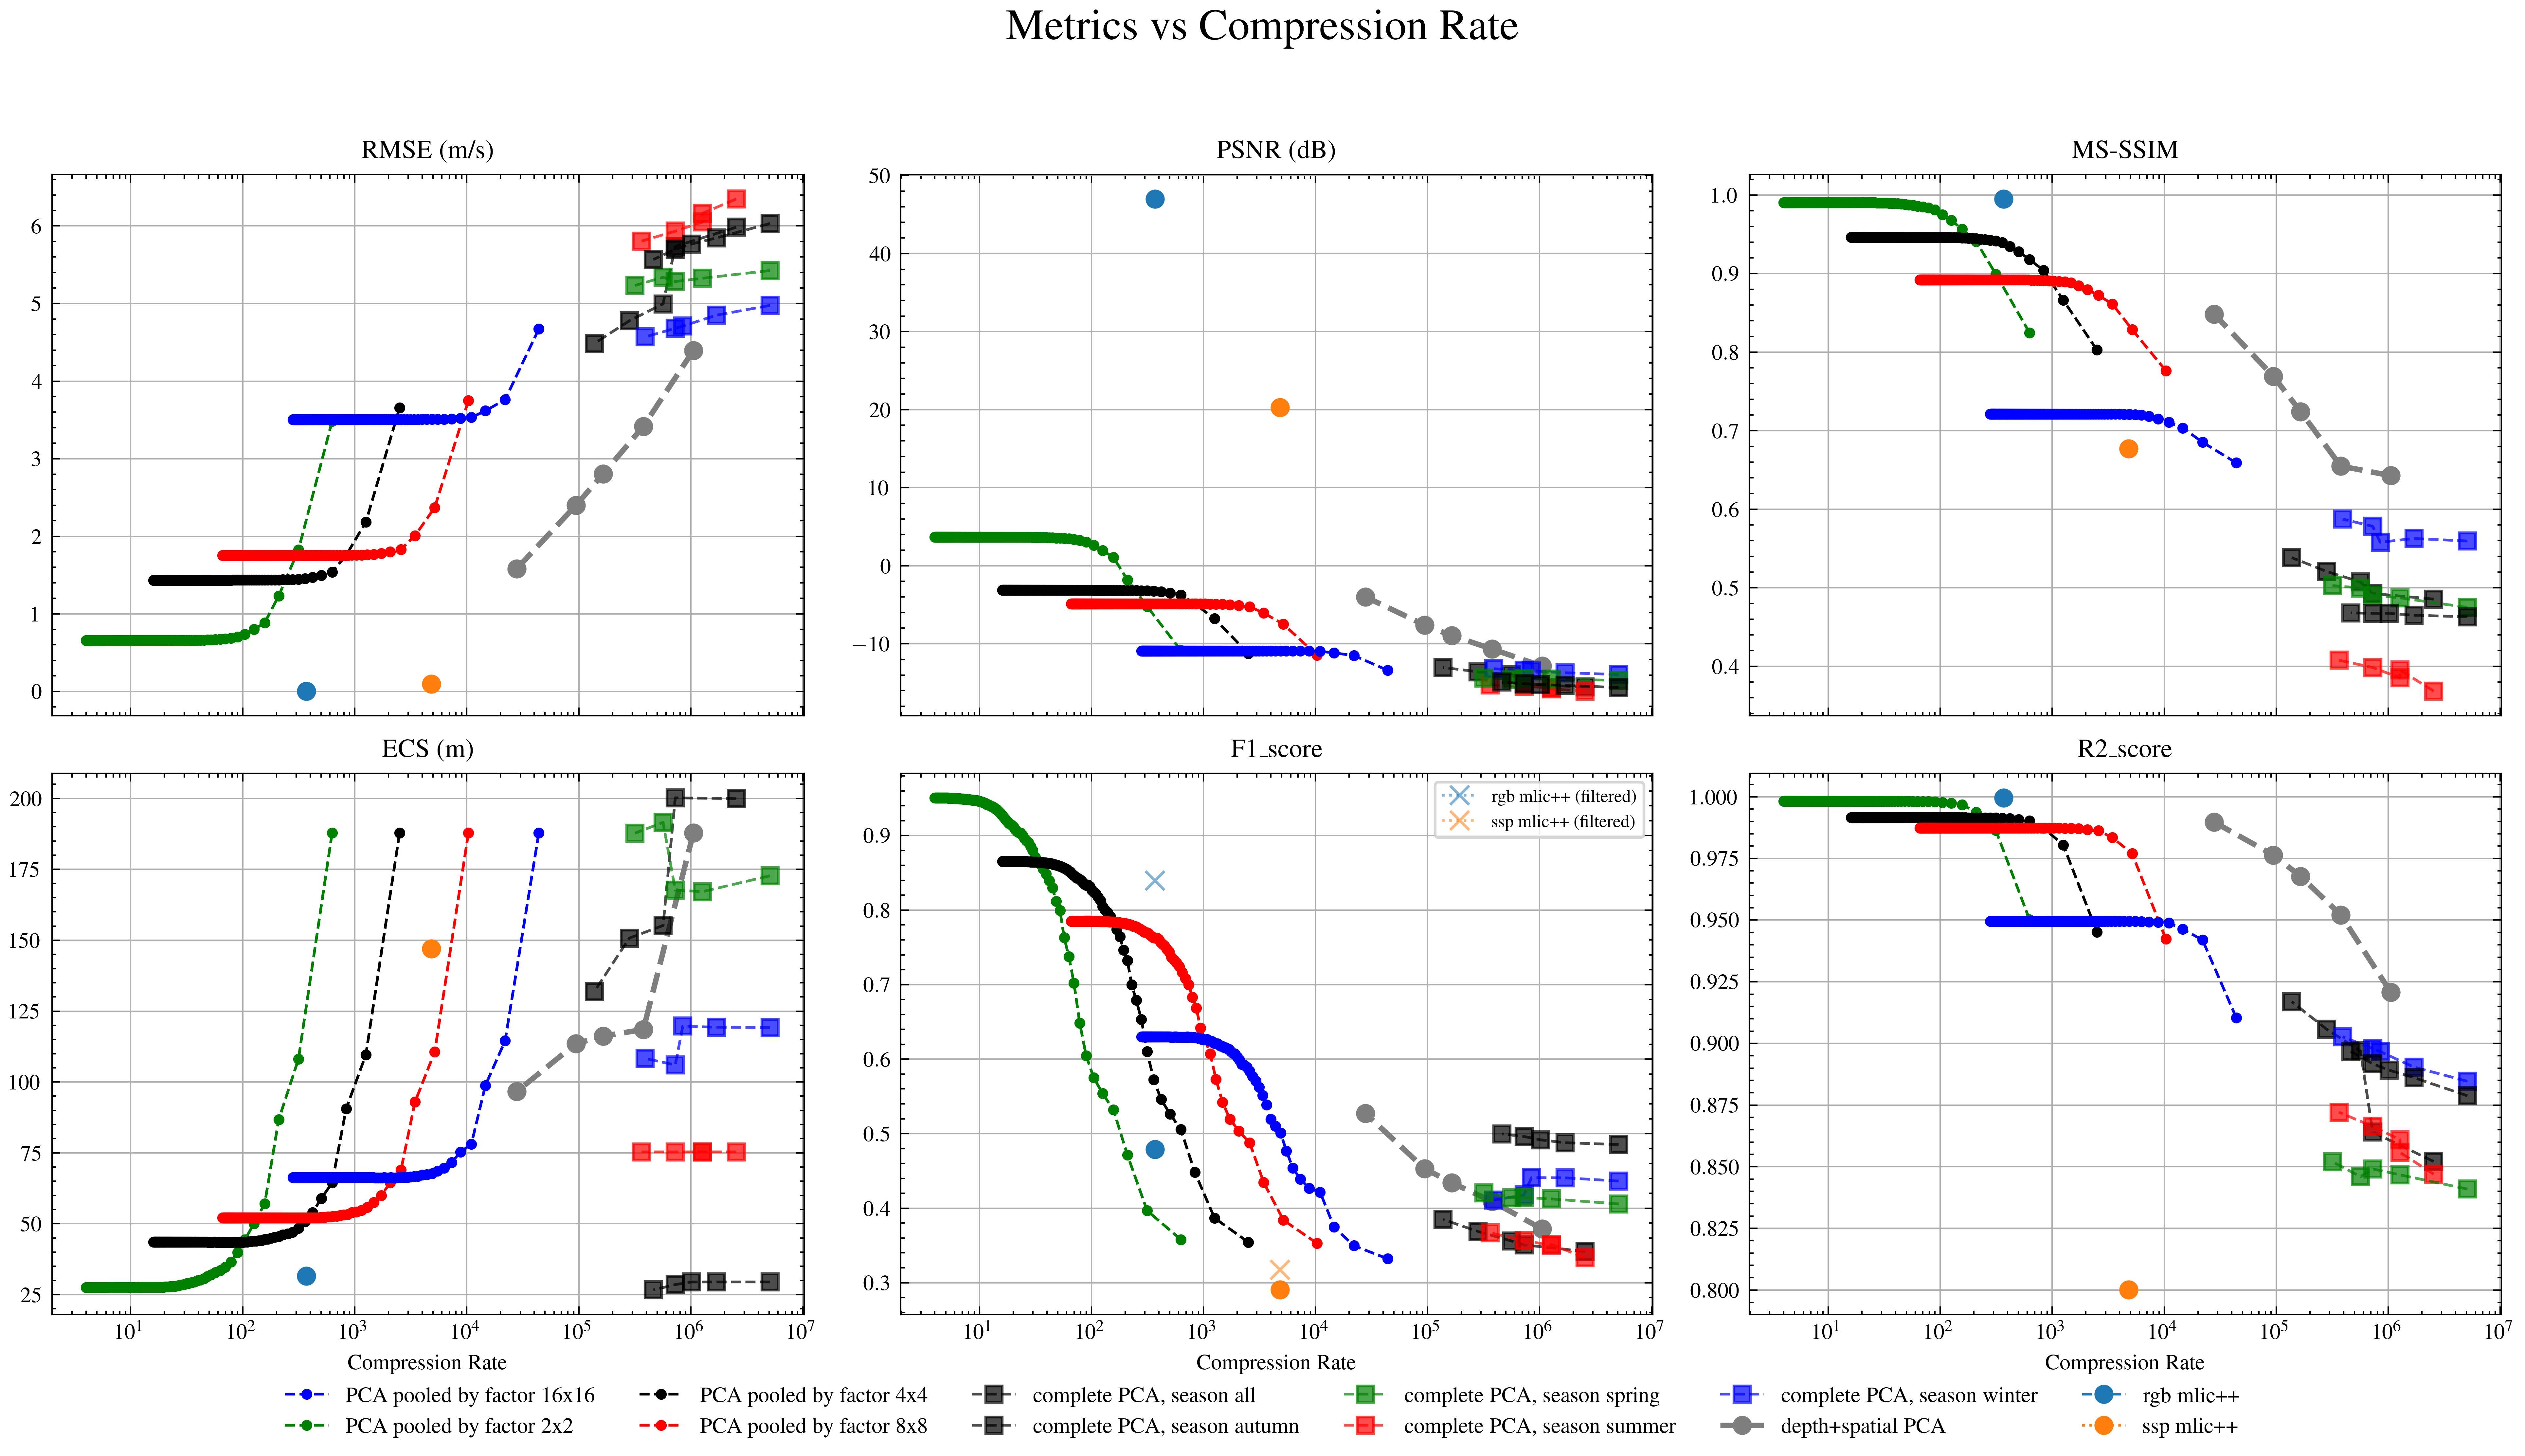

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Use science style
plt.style.use(["science", "ieee"])

# List of metrics with units
metrics = {
    "RMSE": "m/s",
    "PSNR": "dB",
    "MS-SSIM": None,
    "ECS": "m",
    "F1_score": None,
    "R2_score": None
}

n_metrics = len(metrics)
ncols = 3
nrows = int(np.ceil(n_metrics / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows), sharex=True)
axes = axes.flatten()

# Sort models alphabetically for consistent coloring
models = sorted(model_metrics.keys())

# Use a qualitative colormap with enough distinct colors
colors = plt.cm.tab10.colors if len(models) <= 10 else plt.cm.tab20.colors

# Collect handles and labels for the legend
handles, labels = [], []

# Define PCA layers and their numeric identifiers
pca_layer_numbers = [0, 1, 2]  # corresponds to Pool_upsample_0_layers, etc.


# Plot each metric
for idx, (metric, unit) in enumerate(metrics.items()):
    ax = axes[idx]
    filtered_lines = []
    filtered_labels = []

    x_csv = space_depth_pca_metrics_df["CR"]
    y_csv = space_depth_pca_metrics_df[metric]
    csv_line, = ax.plot(
        x_csv, y_csv,
        label="depth+spatial PCA",
        linestyle="--",
        marker="o",
        color="tab:gray",
        linewidth=2
    )
    
    if idx == 0:
        handles.append(csv_line)
        labels.append("depth+spatial PCA")


    # Plot all seasonal DataFrames from season_dfs
    for season, df in season_dfs.items():
        if metric in df.columns:
            ax.plot(
                df["CR"], df[metric],
                label=f"complete PCA, season {season}",
                linestyle="--",
                marker="s",
                alpha=0.7
            )
            if idx == 0:
                handles.append(ax.lines[-1])
                labels.append(f"complete PCA, season {season}")


    # Plot model data
    for i, model in enumerate(models):
        cr_values = sorted(model_metrics[model].keys())
        x = cr_values
        y = [model_metrics[model][cr][metric] for cr in x]
        line, = ax.plot(x, y, label=model, marker='o', color=colors[i % len(colors)])
        if idx == 0:  # Collect legend items only once
            handles.append(line)
            labels.append(model)


        # --- Add Filtered_F1_score if metric is F1_score ---
        if metric == "F1_score":
            y_filt = [model_metrics[model][cr].get("Filtered_F1_score", np.nan) for cr in x]
            filt_line, = ax.plot(
                x, y_filt,
                label=f"{model} (filtered)",
                marker='x',
                color=colors[i % len(colors)],
                alpha=0.55,
                linestyle=':',
                markersize=7
            )
            filtered_lines.append(filt_line)
            filtered_labels.append(f"{model} (filtered)")

    # Add PCA data to the plots

    for pca_model in pca_rmse_dict.keys():

        if pca_model=="PCA":
            continue
        
        cr_values = list(pca_rmse_dict[pca_model].keys())
        y_values = [pca_rmse_dict[pca_model][cr][metric] for cr in cr_values]
        label = pca_model.replace("_", " ")
        line, = ax.plot(cr_values, y_values, label=label, linestyle="--", marker='.')
        if idx == 0:
            handles.append(line)
            labels.append(label)

    ax.set_xscale("log")
    title = f"{metric} ({unit})" if unit else metric
    ax.set_title(title)
    ax.grid(True)
    if idx // ncols == nrows - 1:
        ax.set_xlabel("Compression Rate")

    # Add legend for filtered lines only in F1_score subplot
    if metric == "F1_score" and filtered_lines:
        ax.legend(filtered_lines, filtered_labels, loc="best", fontsize=6.5, frameon=True)

# Hide unused subplots (if any)
for j in range(n_metrics, len(axes)):
    fig.delaxes(axes[j])

sorted_handles_labels = sorted(zip(labels, handles), key=lambda x: x[0])
sorted_labels, sorted_handles = zip(*sorted_handles_labels)

fig.suptitle("Metrics vs Compression Rate", fontsize=16)
fig.tight_layout(rect=[0, 0.05, 1, 0.95])

# Keep the global legend for all curves, sorted by name
fig.legend(
    sorted_handles, 
    sorted_labels, 
    loc='lower center', 
    ncol=int(np.ceil(len(sorted_labels) / 2)), 
    bbox_to_anchor=(0.5, 0.01)
)

plt.show()

In [36]:
column_width = 25
metrics = ["RMSE", "PSNR", "MS-SSIM", "ECS", "MAE", "mean_error_n_min_max", "F1_score", "R2_score", "bpp"]

# Pick the highest CR for each model
selected_cr = {}
for name in model_metrics.keys():
    crs = list(model_metrics[name].keys())
    if crs:
        selected_cr[name] = max(crs)
    else:
        selected_cr[name] = None

header = f'{"Metric":{column_width}s} | ' + ' | '.join([f'{name:{column_width}s}' for name in model_metrics.keys()]) + ' |'
print('-' * len(header))
print(header)
print('-' * len(header))

for metric in metrics:
    print(f'{metric:{column_width}s}', end=' | ')
    for name in model_metrics.keys():
        cr = selected_cr[name]
        if cr is None:
            value = float('nan')
        elif metric == "bpp":
            value = model_metrics[name][cr].get("bits_per_element", float('nan'))
        else:
            value = model_metrics[name][cr].get(metric, float('nan'))
        print(f'{value:{column_width}.3f}', end=' | ')
    print()
print('-' * len(header))

-----------------------------------------------------------------------------------
Metric                    | rgb mlic++                | ssp mlic++                |
-----------------------------------------------------------------------------------
RMSE                      |                     0.004 |                     0.097 | 
PSNR                      |                    46.998 |                    20.279 | 
MS-SSIM                   |                     0.995 |                     0.677 | 
ECS                       |                    31.547 |                   147.036 | 
MAE                       |                     0.003 |                     0.067 | 
mean_error_n_min_max      |                    37.714 |                    97.037 | 
F1_score                  |                     0.479 |                     0.290 | 
R2_score                  |                     1.000 |                     0.800 | 
bpp                       |                       nan |             

# Plot

In [65]:
# t = 10  # Example: first time step
# lat = 10  # Example: first latitude index
# lon = 10  # Example: first longitude index

# # Create a plot for each model in outputs and add ground truth
# plt.figure(figsize=(8, 10))

# # Plot ground truth
# x_ground_truth = test_ssp_arr[t, :, lat, lon]  # Sound speed profile for ground truth
# y = depth_array  # Depth array
# plt.plot(x_ground_truth, y, label="Ground Truth", linestyle="--", color="black")

# # Plot each model's output
# for model_name, ssp_ae_test_arr in outputs.items():
#     # Extract the profile for the given indices
#     x = ssp_ae_test_arr[t, :-3, lat, lon]  # Sound speed profile for the model

#     # Plot the profile
#     plt.plot(x, y[:-3], label=model_name)

# # Add labels, legend, and grid
# plt.gca().invert_yaxis()  # Invert y-axis to show depth increasing downward
# plt.xlabel("Sound Speed (m/s)")
# plt.ylabel("Depth (m)")
# plt.title("Sound Speed Profiles per Model")
# plt.legend()
# plt.grid()
# plt.show()